In [1]:
import sys

from radonpy.core import poly, utils
from radonpy.sim import qm
from radonpy.ff.gaff2 import GAFF2
from radonpy.sim.lammps import MolToLAMMPSdata

from rdkit.Chem import AllChem
from rdkit import Chem
from rdkit.Chem import Draw

import os
import numpy as np

In [2]:
import radonpy.core

# RadonPy

In [3]:
# qm calculations save preliminary and temporary files so we create a directory for them to keep it clean
os.makedirs('.trash2', exist_ok=True)

In [7]:
molecule = utils.mol_from_smiles("*c1ccc(cc1)C(=O)c2ccc(cc2)C(=O)c3ccc(cc3)O*") # molecule is an instance of RDkit.Mol class
# molecule = utils.mol_from_smiles("*CCC*")

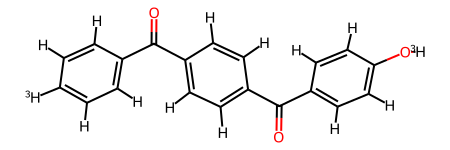

In [8]:
molecule

In [6]:
qm.assign_charges(molecule # charge assignment
              , charge="RESP" # restrained electrostatic potential
              , opt=False
              , work_dir='.trash2/'
              , charge_method="HF"
              , charge_basis="6-31G(d)")

  Threads set to 12 by Python driver.
RadonPy info: Psi4 RESP charge calculation is running...

  Memory set to 953.674 MiB by Python driver.
RadonPy info: Normal termination of psi4 RESP charge calculation. Elapsed time = 0:03:02.988052


True

In [7]:
# Mw
mass = 0
for atom in molecule.GetAtoms():
    mass += atom.GetMass()

mass

306.3450985559998

In [8]:
# num atoms in monomer
num_atoms_mono = molecule.GetNumAtoms() - 2

In [9]:
# num monomers in polymer
MW = 30_000

num_monomers_in_polymer = int(np.ceil(MW / mass))
num_monomers_in_polymer

98

In [10]:
# num polymers in cell
total_num_atoms = 10_000
num_polymers_in_cell = int(np.ceil(total_num_atoms / (num_monomers_in_polymer * num_atoms_mono)))
num_polymers_in_cell

3

In [11]:
polymer_chain = poly.polymerize_rw(molecule, num_monomers_in_polymer) 

RadonPy info: Start polymerize_rw.


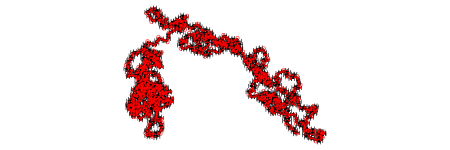

In [12]:
polymer_chain

In [13]:
# Force Field assignment
ff = GAFF2()
chain_parametrized = ff.ff_assign(polymer_chain)

In [14]:
ac = poly.amorphous_cell(polymer_chain,
                         num_polymers_in_cell,
                         density=0.1,
                         retry=1000,
                         retry_step=100)

RadonPy info: Start amorphous cell generation.
RadonPy info: Reached maximum number of retrying step in amorphous_cell.
RadonPy info: Retry amorphous_cell.
RadonPy info: Start amorphous cell generation.
RadonPy info: Reached maximum number of retrying step in amorphous_cell.
RadonPy info: Retry amorphous_cell.
RadonPy info: Start amorphous cell generation.
RadonPy info: Reached maximum number of retrying step in amorphous_cell.
RadonPy info: Retry amorphous_cell.
RadonPy info: Start amorphous cell generation.
RadonPy info: Reached maximum number of retrying step in amorphous_cell.
RadonPy info: Retry amorphous_cell.
RadonPy info: Start amorphous cell generation.


In [15]:
ac

In [16]:
MolToLAMMPSdata(ac, 'pekk.data')

True